Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


['/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/F140M/pipeline/jw06151001001_03109_00007_nrca2_destreak.fits', '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/F140M/pipeline/jw06151001001_03109_00006_nrcb1_destreak.fits', '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/F140M/pipeline/jw06151001001_03109_00002_nrcb2_destreak.fits', '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/F140M/pipeline/jw06151001001_03109_00002_nrcb3_destreak.fits', '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/F140M/pipeline/jw06151001001_03109_00001_nrca2_destreak.fits', '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/F140M/pipeline/jw06151001001_03109_00002_nrcb4_destreak.fits', '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/F140M/pipeline/jw06151001001_03109_00001_nrcb3_destreak.fits', '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/F140M/pipeline/jw06151001001_03109_00007_nrca1_destreak.fits', '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/F140M/pipeline/jw06151001001_03109_00006_nrca3_destreak.fits', '/orange/adamginsburg/w51/T

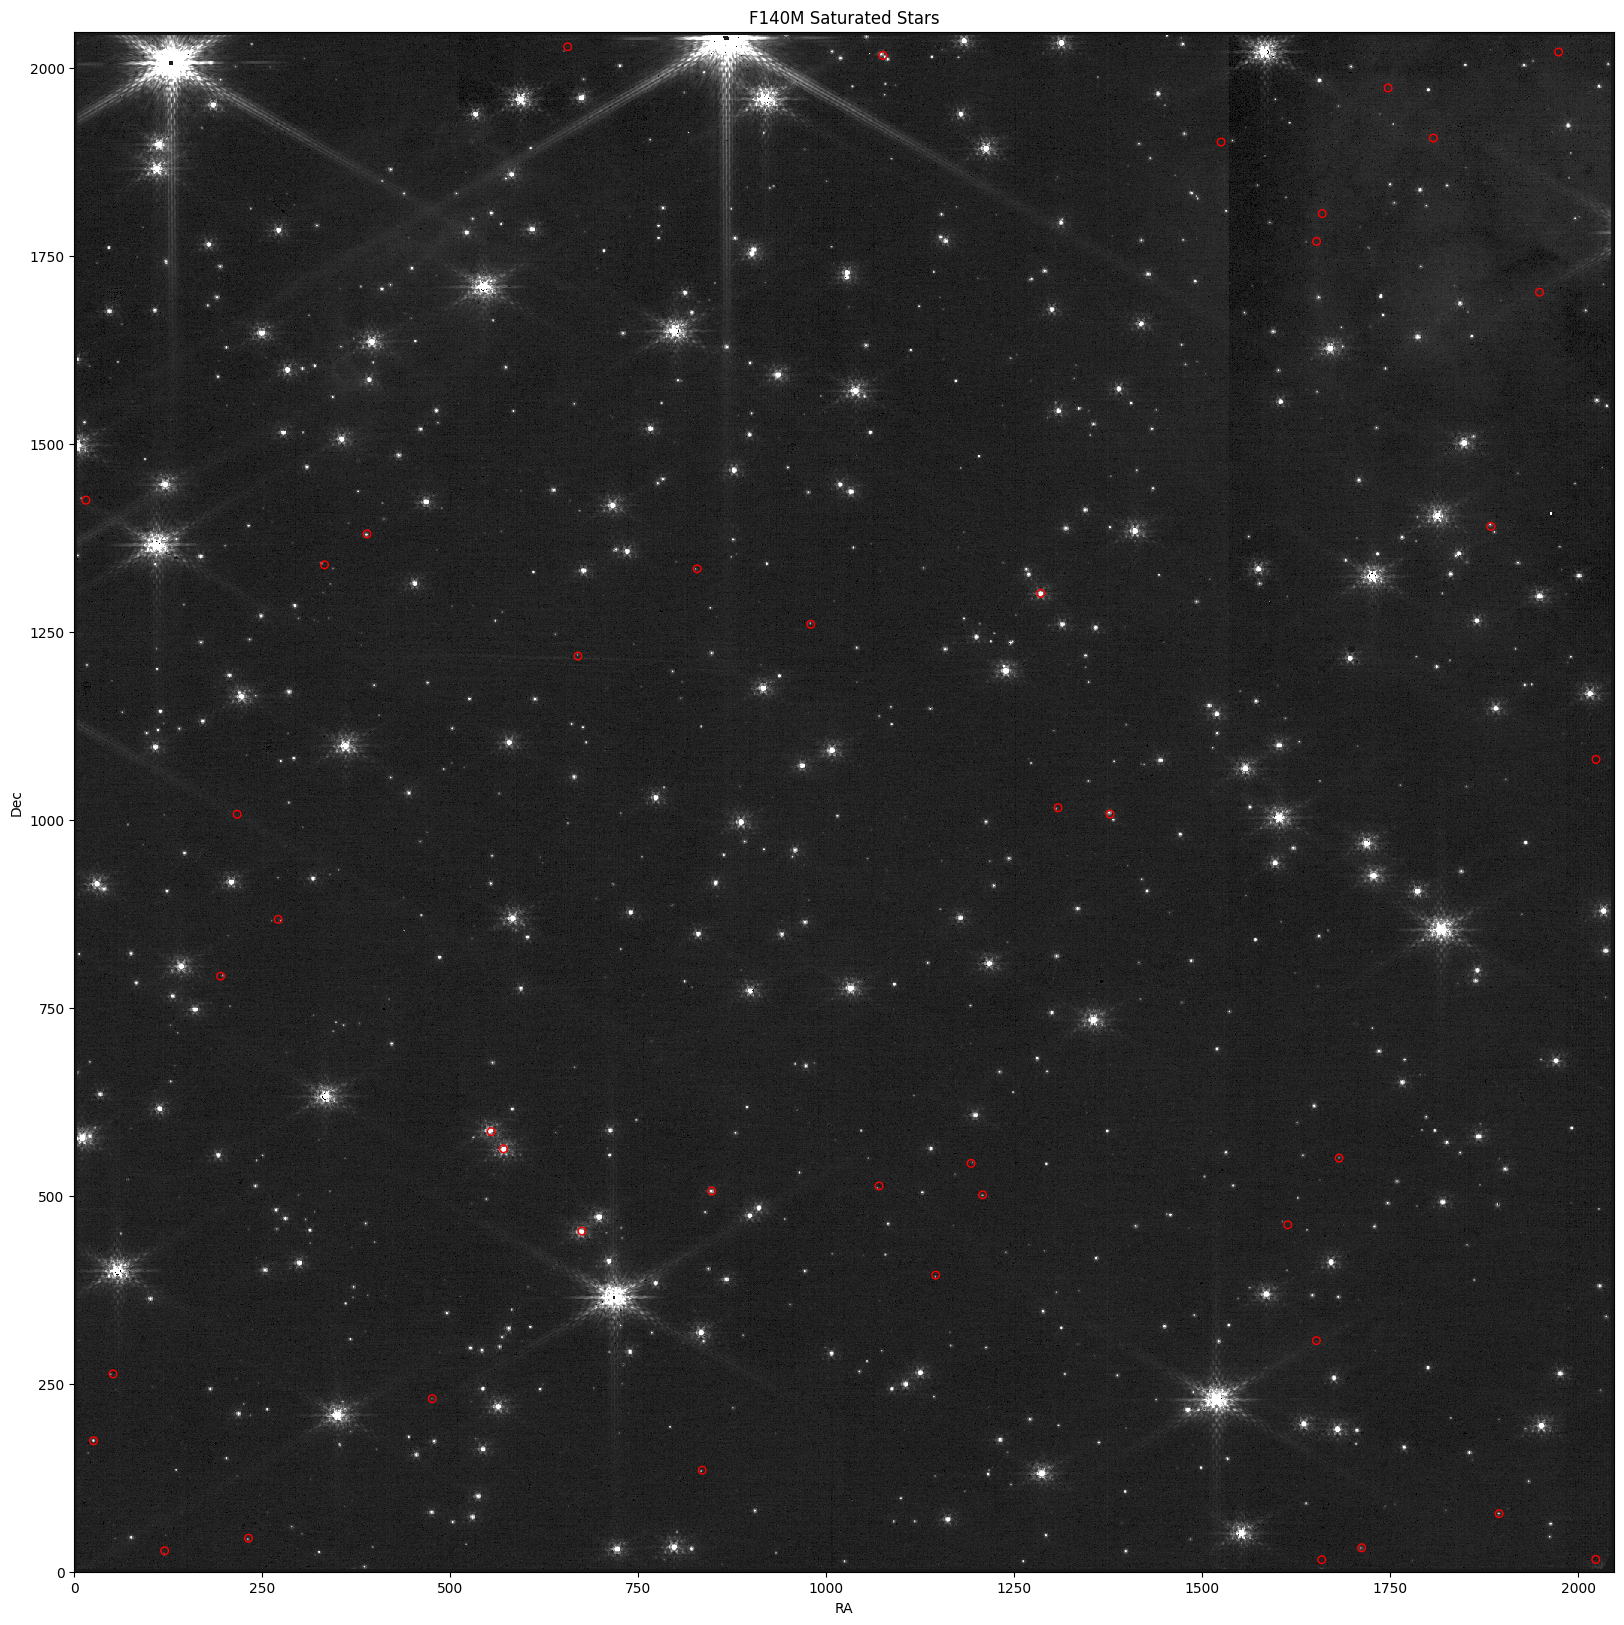

In [ ]:
import glob
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import numpy as np
from regions import Regions
from astropy.nddata import Cutout2D
import astropy.units as u
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
from astropy.table import Table, vstack
from photutils.detection import DAOStarFinder

from astropy import stats

def load_data(filename):
    fh = fits.open(filename)
    im1 = fh
    im1.info()
    try:
        data = im1[1].data
    except:
        data = im1[0].data
    try:
        wht = im1['WHT'].data
    except KeyError:
        wht = None
    
    return fh, im1, data
image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f150w": "/orange/adamginsburg/jwst/w51/F150W/pipeline/jw06151-o001_t001_nircam_clear-f150w-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f1500w": "/orange/adamginsburg/jwst/w51/F1500W/pipeline/jw06151-o002_t001_miri_f1500w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}
tab_original = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_nircam_indivexp_merged_dao_refined.fits')
skycoord_f140_original = tab_original['skycoord']
pixcoords_f140_original = skycoord_f140_original.to_pixel(WCS(fits.getheader(image_filenames['f140m'], ext=('SCI', 1))))
flux_f140_original = tab_original['flux_fit_f140m']
flux_f140_original_unmasked = flux_f140_original.copy()[~flux_f140_original.mask]
flux_sort_idx = np.argsort(flux_f140_original_unmasked)[::-1]
skycoord_f140_original_unmasked = skycoord_f140_original[~flux_f140_original.mask]
pixcoords_f140_original_unmasked = skycoord_f140_original_unmasked.to_pixel(WCS(fits.getheader(image_filenames['f140m'], ext=('SCI', 1))))


image_files = glob.glob(f'/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/F140M/pipeline/*destreak.fits')
print(image_files)
fits_img = fits.open(image_files[0])
fits_img.info()
"""
for i, img_file in enumerate(image_files):
    if i==0:
        if 'f140m' in img_file:
            satstar_cat_f140m = Table.read(img_file)
        pix_scale = 0.031 * u.arcsec
        fwhm_tbl = Table.read('/orange/adamginsburg/jwst/w51/reduction/fwhm_table.ecsv')
        row = fwhm_tbl[fwhm_tbl['Filter'] == 'F140M'][0]
        fwhm = fwhm_arcsec = float(row['PSF FWHM (arcsec)']) * u.arcsec
        fwhm_pix = float(row['PSF FWHM (pixel)']) * u.arcsec / pix_scale

        print(fwhm_pix)
        err = fits.open(img_file)['ERR'].data
        
        img = fits.getdata(img_file)
        filtered_errest = np.nanmedian(err)
        print(f'Using error estimate of {filtered_errest} for DAOStarFinder')

        print("img shape, dtype:", img.shape, img.dtype)
        print("img min/median/max:", np.nanmin(img), np.nanmedian(img), np.nanmax(img))
        print("nan count:", np.isnan(img).sum())
        print("err stats:", np.nanmin(err), np.nanmedian(err), np.nanmax(err), "nan count:", np.isnan(err).sum())
        print("filtered_errest used:", filtered_errest)
        print("fwhm_pix:", fwhm_pix, "type:", type(fwhm_pix))
        print("DAO params: threshold=", 10*filtered_errest, " fwhm=", getattr(fwhm_pix,'value',fwhm_pix))

        img[np.isnan(img)] = 0
        daofind_tuned = DAOStarFinder(threshold=10 * filtered_errest,
                                        fwhm=fwhm_pix.value, roundhi=1.0, roundlo=-1.0,
                                        sharplo=0.30, sharphi=1.40)
        print(daofind_tuned)
        finstars = daofind_tuned(img)
        fig = plt.figure(figsize=(20, 20))
        ax = fig.add_subplot(111)
        norm = simple_norm(img, 'sqrt', percent=99.5)
        ax.imshow(img, norm=norm, origin='lower', cmap='gray', interpolation='nearest')
        ax.set_xlabel('RA')
        ax.set_ylabel('Dec')
        ax.set_title('F140M Saturated Stars')
        #ax.scatter(pixcoords_f140_original_unmasked[0][flux_sort_idx[:400]], pixcoords_f140_original_unmasked[1][flux_sort_idx[:400]], s=50, edgecolor='blue', facecolor='none', marker='o', label='400 brightest star in the original catalog')
        print(finstars)
        ax.scatter(finstars['xcentroid'], finstars['ycentroid'], s=30, edgecolor='red', facecolor='none', marker='o', label='Detected stars with DAOStarFinder')
        #ax.scatter(pixcoords_f140_original_unmasked[0][flux_sort_idx[:400]], pixcoords_f140_original_unmasked[1][flux_sort_idx[:400]], s=50, edgecolor='blue', facecolor='none', marker='o', label='400 brightest star in the original catalog')

        ax.set_xlim(0, img.shape[1])
        ax.set_ylim(0, img.shape[0])
        plt.show()
"""


In [ ]:
image_files = glob.glob(f'/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/F140M/pipeline/*destreak.fits')

cat_files = glob.glob(f'/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/{filter}/pipeline/*destreak*satstar_catalog.fits')
"""
wav = filter[1:-1]
if int(wav)<300:
    pixel_scale = 0.031 * u.arcsec
else:
    pixel_scale = 0.063 * u.arcsec
"""
fwhm_tbl = Table.read('/orange/adamginsburg/jwst/w51/reduction/fwhm_table.ecsv')
row = fwhm_tbl[fwhm_tbl['Filter'] == filter.upper()]
fwhm = u.Quantity(float(row['PSF FWHM (arcsec)'][0]), u.arcsec)
print(f"Using FWHM={fwhm:.3f}")

for i, f in enumerate(image_files):
    sat_cat = f.split('.')[0]+'_satstar_catalog.fits'

    sat_hdul = fits.open(sat_cat)
    

    # column names: use the FITS API that exists on BinTableHDU
    try:
        colnames = sat_hdul[1].columns.names
    except Exception:
        # fallback to numpy dtype names if columns isn't available
        try:
            colnames = list(sat_hdul[1].data.dtype.names)
        except Exception:
            colnames = None
    tab = sat_hdul[1].data
    xpos = tab['x_fit']
    ypos = tab['y_fit']

    